In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno

# Load the dataset
train_df = pd.read_csv("../data/train.csv")


Rows with at least one missing value: 10734 out of 10853 (98.90%)

Missing Value Overlap (Number of missing values per row):


0      119
1      525
2     1284
3     2052
4     2173
5     1913
6     1356
7      786
8      395
9      177
10      52
11      16
12       3
13       2
Name: count, dtype: int64

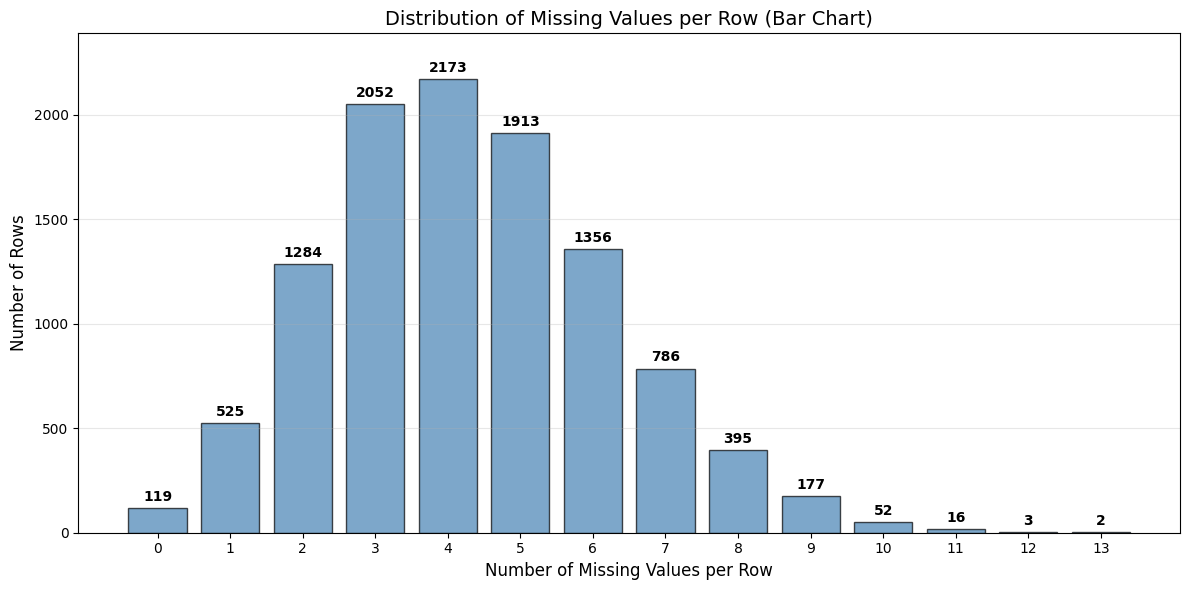

<Figure size 1600x800 with 0 Axes>

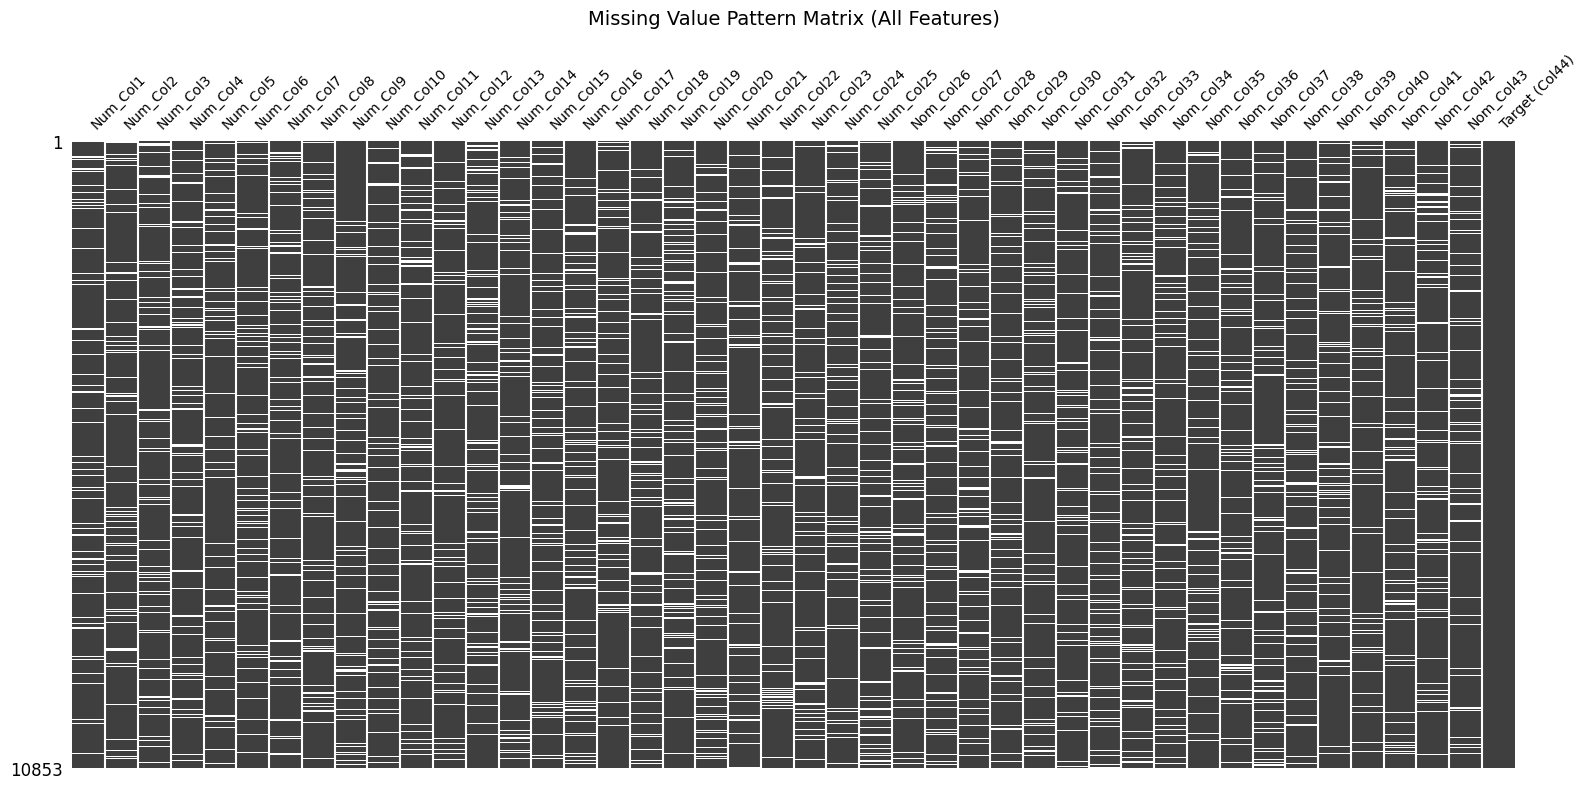

In [3]:
# Calculate the number of rows with missing values
rows_with_missing = train_df.isnull().any(axis=1).sum()

# Calculate missing value overlap
missing_overlap = train_df.isnull().sum(axis=1).value_counts()
print(
    f"\nRows with at least one missing value: {rows_with_missing} out of {len(train_df)} ({(rows_with_missing / len(train_df) * 100):.2f}%)"
)
print("\nMissing Value Overlap (Number of missing values per row):")
display(missing_overlap.sort_index())

# Visualize missing value overlap
plt.figure(figsize=(12, 6))
bars = plt.bar(
    missing_overlap.index,
    missing_overlap.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.7,
)

# Add value labels above each bar.
for i, (idx, val) in enumerate(zip(missing_overlap.index, missing_overlap.values)):
    plt.text(
        idx,
        val + 20,
        str(val),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.xlabel("Number of Missing Values per Row", fontsize=12)
plt.ylabel("Number of Rows", fontsize=12)
plt.title("Distribution of Missing Values per Row (Bar Chart)", fontsize=14)
plt.grid(axis="y", alpha=0.3)

# Set x-axis ticks to ensure all values are displayed
plt.xticks(missing_overlap.index)
# Set the y-axis range slightly above the maximum value to display the label.
plt.ylim(0, missing_overlap.max() * 1.1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
msno.matrix(train_df, figsize=(16, 8), fontsize=10, sparkline=False)
plt.title("Missing Value Pattern Matrix (All Features)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()